In [1]:
# ── BLOCO 0 CORRIGIDO v2 ─────────────────────────────────────────────────────

!pip install -q numpy==1.26.4
!pip install -q pandas==2.2.2
!pip install -q spacy==3.7.4
!pip install -q nltk==3.8.1
!pip install -q langdetect==1.0.9

# Modelos spaCy — instalação direta pelo .whl (URL correta para v3.7.x)
!pip install -q https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.7.0/pt_core_news_sm-3.7.0-py3-none-any.whl
!pip install -q https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl
print("✅ Tudo instalado com sucesso!")
print("⚠️  Agora: Runtime → Restart session → Run all")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 69.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.6 MB/s eta 0:00:00
✅ Tudo instalado com sucesso!
⚠️  Agora: Runtime → Restart session → Run all


# 🔧 Projeto Forzy — Digital Twin para Manutenção Preditiva
## `sprint1_pln_corpus.ipynb` · Pipeline NLP — Fundamentos do Ativo
### Challenge FIAP · Processamento de Linguagem Natural

---

> **Contexto:** Solução de digital twin para monitoramento e manutenção preditiva de motores elétricos industriais. Este notebook implementa o pipeline completo de pré-processamento textual e geração do corpus estruturado que sustentará todos os módulos de PLN do projeto.

| Bloco | Etapa | Entregável |
|-------|-------|------------|
| 0 | Setup e estrutura de diretórios | Ambiente reprodutível |
| 1 | Dataset sintético | `forzy_corpus_raw.csv` |
| 2 | Glossário técnico PT/EN | `forzy_glossario_tecnico.json` |
| 3 | Pipeline de pré-processamento | Funções modulares documentadas |
| 4 | Análise estatística | Métricas + visualizações |
| 5 | Avaliação: Lematização vs Stemming | Comparação quantitativa |
| 6 | Corpus estruturado e exportação | `forzy_corpus_estruturado.json` |

**Autores:** Equipe Forzy  
**Versão:** 1.0.0  
**Última atualização:** 2025-01

---
## ⚙️ Bloco 0 — Setup, Dependências e Estrutura de Diretórios

### Por que este bloco existe?
Garantir reprodutibilidade total: qualquer pessoa que clonar o repositório e executar este notebook do zero obterá os mesmos resultados. Fixamos versões de bibliotecas e criamos a estrutura de diretórios padronizada do projeto.

In [2]:
# ── 0.1 Instalação de dependências com versões fixadas ───────────────────────
# Execute este bloco UMA VEZ por sessão Colab.
# Tempo estimado: 2–3 minutos (download dos modelos spaCy)

!pip install spacy==3.7.4 nltk==3.8.1 langdetect==1.0.9 matplotlib==3.8.3 --quiet

# Modelos spaCy para lematização bilíngue
!python -m spacy download pt_core_news_sm --quiet   # Português
!python -m spacy download en_core_web_sm  --quiet   # Inglês

print("✅ Dependências instaladas!")
print("   spaCy 3.7.4 | NLTK 3.8.1 | langdetect 1.0.9")

  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-pt_core_news_sm/-pt_core_news_sm.tar.gz
ERROR: Could not install requirement https://github.com/explosion/spacy-models/releases/download/-pt_core_news_sm/-pt_core_news_sm.tar.gz because of HTTP error 404 Client Error: Not Found for url: https://github.com/explosion/spacy-models/releases/download/-pt_core_news_sm/-pt_core_news_sm.tar.gz for URL https://github.com/explosion/spacy-models/releases/download/-pt_core_news_sm/-pt_core_news_sm.tar.gz
  ERROR: HTTP error 404 while getting https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz
ERROR: Could not install requirement https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz because of HTTP error 404 Client Error: Not Found for url: https://github.com/explosion/spacy-models/releases/download/-en_core_web_sm/-en_core_web_sm.tar.gz for URL https://github.

In [3]:
# ── 0.2 Imports ──────────────────────────────────────────────────────────────
import re
import json
import os
import unicodedata
from datetime import date
from collections import Counter
from pathlib import Path

import pandas as pd
import spacy
import nltk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from langdetect import detect, DetectorFactory

# NLTK: stemmer para português e inglês
nltk.download('rslp',    quiet=True)  # RSLP — stemmer para PT
nltk.download('punkt',   quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.stem import RSLPStemmer, PorterStemmer

# Seed para reprodutibilidade do langdetect
DetectorFactory.seed = 42

# Carrega modelos spaCy
NLP_PT = spacy.load("pt_core_news_sm")
NLP_EN = spacy.load("en_core_web_sm")

# Stemmers
STEMMER_PT = RSLPStemmer()
STEMMER_EN = PorterStemmer()

print("✅ Todos os imports carregados com sucesso!")

✅ Todos os imports carregados com sucesso!


In [4]:
# ── 0.3 Estrutura de diretórios do projeto ───────────────────────────────────
# Convenção: todos os artefatos têm prefixo 'forzy_' e usam snake_case

DIRS = {
    "raw":       Path("forzy_sprint1/data/raw"),
    "processed": Path("forzy_sprint1/data/processed"),
    "docs":      Path("forzy_sprint1/docs"),
    "outputs":   Path("forzy_sprint1/outputs"),
}

for name, path in DIRS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"   📁 {path}")

# Caminhos canônicos dos artefatos
PATHS = {
    "raw_csv":        DIRS["raw"]       / "forzy_corpus_raw.csv",
    "glossario":      DIRS["docs"]      / "forzy_glossario_tecnico.json",
    "corpus_json":    DIRS["processed"] / "forzy_corpus_estruturado.json",
    "stats_json":     DIRS["processed"] / "forzy_corpus_stats.json",
    "plot_analise":   DIRS["outputs"]   / "forzy_analise_corpus.png",
    "plot_lemvstem":  DIRS["outputs"]   / "forzy_comparacao_lemma_stem.png",
    "decisoes_md":    DIRS["docs"]      / "decisoes_padronizacao.md",
}

print("\n✅ Estrutura de diretórios criada!")
print("\nNaming Convention:")
print("  • Prefixo:    forzy_")
print("  • Case:       snake_case")
print("  • Sem acentos nos nomes de arquivo")
print("  • Versionamento: forzy_<artefato>_v{N}.<ext>")

   📁 forzy_sprint1/data/raw
   📁 forzy_sprint1/data/processed
   📁 forzy_sprint1/docs
   📁 forzy_sprint1/outputs

✅ Estrutura de diretórios criada!

Naming Convention:
  • Prefixo:    forzy_
  • Case:       snake_case
  • Sem acentos nos nomes de arquivo
  • Versionamento: forzy_<artefato>_v{N}.<ext>


---
## 📋 Bloco 1 — Dataset Sintético com Metadados Completos

### Por que este design?
O dataset replica a heterogeneidade real de fontes industriais: placas de equipamento (*nameplate*), fichas de cadastro ERP, ordens de serviço e logs de operação. Cada registro inclui todos os campos obrigatórios do cadastro do ativo definidos nas **Decisões de Padronização** (ver `decisoes_padronizacao.md`).

**Campos obrigatórios:**
- `tag` → Identificador único no formato `{PLANTA}-{AREA}-{TIPO}{SEQ}`
- `descricao_curta` + `descricao_longa` → Descrição do ativo
- `fabricante` → Vocabulário controlado
- `localizacao` → Hierarquia `PLANTA.AREA.POSICAO`
- `especificacao_tecnica` → Dict com parâmetros mensuráveis
- `fonte` → Origem do texto (`placa`, `manual`, `cadastro_erp`, `log_operacao`)
- `data_extracao` + `idioma` → Rastreabilidade

In [5]:
# ── 1.1 Dataset sintético — 30 registros multilíngues com metadados ──────────
DATA_EXTRACAO = str(date.today())

raw_data = [
    # ── GRUPO 1: Placas de equipamento (nameplate) — PT ──────────────────────
    {"id": 1,
     "tag": "USI01-COMP-MT001",
     "descricao_curta": "MOTOR WEG W22 50HP 4P",
     "descricao_longa": "Motor WEG W22 50HP tens. 440V rot. 1800rpm freq. 60Hz IP55 class. F",
     "fabricante": "WEG", "modelo": "W22-50HP-4P-440V",
     "localizacao": "USI01.COMP.L1-P1",
     "especificacao_tecnica": {"potencia_hp": 50, "potencia_kw": 37.3, "tensao_v": 440, "rotacao_rpm": 1800, "frequencia_hz": 60, "polos": 4},
     "fonte": "placa", "categoria": "nameplate", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 2,
     "tag": "USI01-BOMB-MB002",
     "descricao_curta": "MOTOR WEG W22 IE3 15KW 4P",
     "descricao_longa": "Motor Elétrico Trifásico WEG W22 IE3 15kW corr. 28.8A pot. 15kW rot. 1750rpm freq. 60Hz IP55",
     "fabricante": "WEG", "modelo": "W22-15KW-4P-IE3",
     "localizacao": "USI01.BOMB.L2-P3",
     "especificacao_tecnica": {"potencia_kw": 15, "corrente_a": 28.8, "rotacao_rpm": 1750, "frequencia_hz": 60, "polos": 4, "eficiencia_ie": "IE3"},
     "fonte": "placa", "categoria": "nameplate", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 3,
     "tag": "USI02-VENT-MV003",
     "descricao_curta": "MOTOR SIEMENS 1LE1 75KW",
     "descricao_longa": "Motor Siemens 1LE1 75kW rot. 3550rpm tens. 380/660V corr. 135A IP55 class. F IE3 freq. 60Hz",
     "fabricante": "SIEMENS", "modelo": "1LE1-75KW-2P",
     "localizacao": "USI02.VENT.L1-P2",
     "especificacao_tecnica": {"potencia_kw": 75, "corrente_a": 135, "tensao_v": "380/660", "rotacao_rpm": 3550, "frequencia_hz": 60, "polos": 2},
     "fonte": "placa", "categoria": "nameplate", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 4,
     "tag": "USI02-COMP-MT004",
     "descricao_curta": "MOTOR ABB M3BP 55KW IP65",
     "descricao_longa": "Motor ABB M3BP 55kW 4 polos tens. 380-690V IP65 IE3 class. F rot. 1480rpm",
     "fabricante": "ABB", "modelo": "M3BP-55KW-4P-IP65",
     "localizacao": "USI02.COMP.L3-P1",
     "especificacao_tecnica": {"potencia_kw": 55, "tensao_v": "380-690", "rotacao_rpm": 1480, "polos": 4, "ip": "IP65"},
     "fonte": "placa", "categoria": "nameplate", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 5,
     "tag": "USI03-TRAT-MT005",
     "descricao_curta": "MOTOR GE 200HP 2300V",
     "descricao_longa": "Motor GE 200HP tens. 2300V rot. 1780rpm freq. 60Hz class. F IP54 trifásico 2 polos",
     "fabricante": "GE", "modelo": "GE-200HP-2P-2300V",
     "localizacao": "USI03.TRAT.L1-P1",
     "especificacao_tecnica": {"potencia_hp": 200, "potencia_kw": 149.1, "tensao_v": 2300, "rotacao_rpm": 1780, "frequencia_hz": 60, "polos": 2},
     "fonte": "placa", "categoria": "nameplate", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 2: Placas de equipamento (nameplate) — EN ───────────────────────
    {"id": 6,
     "tag": "USI01-COMP-MT006",
     "descricao_curta": "MOTOR BALDOR 100HP 460V",
     "descricao_longa": "Electric Motor Baldor 3-Phase 60Hz 100HP 460V 1800rpm NEMA Frame 405T IP55 insulation class F",
     "fabricante": "BALDOR", "modelo": "BALDOR-100HP-4P-460V",
     "localizacao": "USI01.COMP.L1-P2",
     "especificacao_tecnica": {"potencia_hp": 100, "tensao_v": 460, "rotacao_rpm": 1800, "frequencia_hz": 60, "frame": "405T"},
     "fonte": "placa", "categoria": "nameplate", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 7,
     "tag": "USI03-BOMB-MB007",
     "descricao_curta": "MOTOR ABB M3AA 30KW IP54",
     "descricao_longa": "ABB M3AA 30kW 4-pole 380-690V IP54 IE3 efficiency class insulation class F 1475rpm 60Hz",
     "fabricante": "ABB", "modelo": "M3AA-30KW-4P",
     "localizacao": "USI03.BOMB.L2-P1",
     "especificacao_tecnica": {"potencia_kw": 30, "tensao_v": "380-690", "rotacao_rpm": 1475, "polos": 4, "ip": "IP54", "eficiencia_ie": "IE3"},
     "fonte": "placa", "categoria": "nameplate", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 8,
     "tag": "USI02-VENT-MV008",
     "descricao_curta": "MOTOR SIEMENS SIMOTICS 22KW",
     "descricao_longa": "Siemens SIMOTICS SD 22kW 6-pole 380-660V 60Hz IP55 IE3 class F 980rpm cooling IC411",
     "fabricante": "SIEMENS", "modelo": "SIMOTICS-SD-22KW-6P",
     "localizacao": "USI02.VENT.L2-P3",
     "especificacao_tecnica": {"potencia_kw": 22, "tensao_v": "380-660", "rotacao_rpm": 980, "polos": 6, "frequencia_hz": 60},
     "fonte": "placa", "categoria": "nameplate", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 3: Ordens de serviço — PT ───────────────────────────────────────
    {"id": 9,
     "tag": "USI01-COMP-MT001",
     "descricao_curta": "OS - ROLAMENTO DIANTEIRO DESGASTADO",
     "descricao_longa": "Substituição rolamento dianteiro 6308-2RS por desgaste prematuro — vibração 9.2 mm/s RMS zona D",
     "fabricante": "WEG", "modelo": "W22-50HP-4P-440V",
     "localizacao": "USI01.COMP.L1-P1",
     "especificacao_tecnica": {"cod_rolamento": "6308-2RS", "vibracao_mms": 9.2, "zona_iso": "D"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 10,
     "tag": "USI02-COMP-MT004",
     "descricao_curta": "OS - CURTO ENTRE ESPIRAS ESTATOR",
     "descricao_longa": "Falha no enrolamento do estator — curto-circuito entre espiras fase B — corrente assimétrica 15% desvio",
     "fabricante": "ABB", "modelo": "M3BP-55KW-4P-IP65",
     "localizacao": "USI02.COMP.L3-P1",
     "especificacao_tecnica": {"fase_afetada": "B", "desvio_corrente_pct": 15, "tipo_falha": "curto_espiras"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 11,
     "tag": "USI01-BOMB-MB002",
     "descricao_curta": "OS - DESALINHAMENTO ACOPLAMENTO",
     "descricao_longa": "Desalinhamento radial 0.18mm no acoplamento — eixo motor deslocado — vibração axial elevada",
     "fabricante": "WEG", "modelo": "W22-15KW-4P-IE3",
     "localizacao": "USI01.BOMB.L2-P3",
     "especificacao_tecnica": {"desalinhamento_mm": 0.18, "tipo": "radial"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 12,
     "tag": "USI03-TRAT-MT005",
     "descricao_curta": "OS - SUPERAQUECIMENTO ESTATOR",
     "descricao_longa": "Temperatura estator acima do limite class. F — temp. medida 168°C — motor parado por proteção térmica",
     "fabricante": "GE", "modelo": "GE-200HP-2P-2300V",
     "localizacao": "USI03.TRAT.L1-P1",
     "especificacao_tecnica": {"temperatura_c": 168, "limite_classe_f_c": 155, "tipo_falha": "superaquecimento"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 13,
     "tag": "USI02-VENT-MV003",
     "descricao_curta": "OS - RELUBRIFICACAO ROLAMENTO",
     "descricao_longa": "Relubrificação preventiva rolamento 6310 mancal traseiro — graxa SKF LGHP2 25g — intervalo 2000h",
     "fabricante": "SIEMENS", "modelo": "1LE1-75KW-2P",
     "localizacao": "USI02.VENT.L1-P2",
     "especificacao_tecnica": {"cod_rolamento": "6310", "graxa": "SKF LGHP2", "quantidade_g": 25, "intervalo_h": 2000},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 14,
     "tag": "USI01-COMP-MT006",
     "descricao_curta": "OS - TROCA VENTOINHA DANIFICADA",
     "descricao_longa": "Ventoinha de resfriamento danificada por objeto estranho — temp. ambiente 47°C — motor em superaquecimento",
     "fabricante": "BALDOR", "modelo": "BALDOR-100HP-4P-460V",
     "localizacao": "USI01.COMP.L1-P2",
     "especificacao_tecnica": {"temperatura_ambiente_c": 47, "causa": "objeto_estranho", "tipo_falha": "superaquecimento"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 4: Ordens de serviço — EN ───────────────────────────────────────
    {"id": 15,
     "tag": "USI03-BOMB-MB007",
     "descricao_curta": "WO - BEARING FAILURE DETECTED",
     "descricao_longa": "Bearing failure detected — vibration 12.4 mm/s RMS on DE bearing — FFT shows inner race defect frequency",
     "fabricante": "ABB", "modelo": "M3AA-30KW-4P",
     "localizacao": "USI03.BOMB.L2-P1",
     "especificacao_tecnica": {"vibracao_mms": 12.4, "localizacao_falha": "DE_bearing", "modo_falha": "inner_race"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 16,
     "tag": "USI02-VENT-MV008",
     "descricao_curta": "WO - STATOR INSULATION BELOW LIMIT",
     "descricao_longa": "Stator winding insulation resistance measured at 0.8 MΩ — below 1 MΩ minimum threshold — rewind required",
     "fabricante": "SIEMENS", "modelo": "SIMOTICS-SD-22KW-6P",
     "localizacao": "USI02.VENT.L2-P3",
     "especificacao_tecnica": {"resistencia_isolamento_mohm": 0.8, "limite_minimo_mohm": 1.0, "acao": "rebobinamento"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 17,
     "tag": "USI01-COMP-MT001",
     "descricao_curta": "WO - ROTOR BAR BROKEN",
     "descricao_longa": "Replace rotor bars — broken bar detected via FFT current signature analysis — sidebands at 1±2s frequency",
     "fabricante": "WEG", "modelo": "W22-50HP-4P-440V",
     "localizacao": "USI01.COMP.L1-P1",
     "especificacao_tecnica": {"metodo_diagnostico": "MCSA_FFT", "tipo_falha": "broken_rotor_bar"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 18,
     "tag": "USI03-TRAT-MT005",
     "descricao_curta": "WO - OVERCURRENT PHASE IMBALANCE",
     "descricao_longa": "Overcurrent protection trip — phase current imbalance 9.5% on stator — check supply voltage balance",
     "fabricante": "GE", "modelo": "GE-200HP-2P-2300V",
     "localizacao": "USI03.TRAT.L1-P1",
     "especificacao_tecnica": {"desequilibrio_corrente_pct": 9.5, "tipo_falha": "sobrecorrente"},
     "fonte": "log_operacao", "categoria": "ordem_servico", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 5: Laudos técnicos — PT ─────────────────────────────────────────
    {"id": 19,
     "tag": "USI01-BOMB-MB002",
     "descricao_curta": "LAUDO - ISOLAMENTO ESTATOR DEGRADADO",
     "descricao_longa": "Isolamento estator class. F degradado — umidade interna 87% — resistência isolamento 1.2 MΩ — rebobinamento preventivo recomendado",
     "fabricante": "WEG", "modelo": "W22-15KW-4P-IE3",
     "localizacao": "USI01.BOMB.L2-P3",
     "especificacao_tecnica": {"umidade_pct": 87, "resistencia_isolamento_mohm": 1.2, "condicao": "degradado"},
     "fonte": "laudo_tecnico", "categoria": "laudo", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 20,
     "tag": "USI02-COMP-MT004",
     "descricao_curta": "LAUDO - VIBRAÇÃO DESBALANCEAMENTO ROTOR",
     "descricao_longa": "Rotor com desbalanceamento 45 g.mm — vibração radial 6.8 mm/s zona C — balanceamento dinâmico necessário",
     "fabricante": "ABB", "modelo": "M3BP-55KW-4P-IP65",
     "localizacao": "USI02.COMP.L3-P1",
     "especificacao_tecnica": {"desbalanceamento_gmm": 45, "vibracao_mms": 6.8, "zona_iso": "C", "acao": "balanceamento_dinamico"},
     "fonte": "laudo_tecnico", "categoria": "laudo", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 6: Laudos técnicos — EN ─────────────────────────────────────────
    {"id": 21,
     "tag": "USI02-VENT-MV008",
     "descricao_curta": "REPORT - SHAFT MISALIGNMENT DETECTED",
     "descricao_longa": "Shaft misalignment 0.15mm radial on coupling — axial vibration dominant — laser alignment correction required",
     "fabricante": "SIEMENS", "modelo": "SIMOTICS-SD-22KW-6P",
     "localizacao": "USI02.VENT.L2-P3",
     "especificacao_tecnica": {"desalinhamento_mm": 0.15, "tipo": "radial", "acao": "alinhamento_laser"},
     "fonte": "laudo_tecnico", "categoria": "laudo", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 22,
     "tag": "USI03-BOMB-MB007",
     "descricao_curta": "REPORT - WINDING THERMAL DEGRADATION",
     "descricao_longa": "Thermal imaging shows hotspot 172°C on phase A winding — exceeds class F limit 155°C — immediate shutdown recommended",
     "fabricante": "ABB", "modelo": "M3AA-30KW-4P",
     "localizacao": "USI03.BOMB.L2-P1",
     "especificacao_tecnica": {"temperatura_ponto_quente_c": 172, "limite_classe_f_c": 155, "fase_afetada": "A"},
     "fonte": "laudo_tecnico", "categoria": "laudo", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 7: Fichas de cadastro ERP — misto PT/EN ─────────────────────────
    {"id": 23,
     "tag": "USI01-COMP-MT001",
     "descricao_curta": "CADASTRO ERP MT001",
     "descricao_longa": "Motor WEG 50HP tensão 440V RPM 1800 — NEMA frame 326T — duty S1 continuous — IP55 — classe isolamento F",
     "fabricante": "WEG", "modelo": "W22-50HP-4P-440V",
     "localizacao": "USI01.COMP.L1-P1",
     "especificacao_tecnica": {"frame_nema": "326T", "regime_servico": "S1"},
     "fonte": "cadastro_erp", "categoria": "ficha_cadastro", "idioma": "misto", "data_extracao": DATA_EXTRACAO},

    {"id": 24,
     "tag": "USI02-VENT-MV003",
     "descricao_curta": "CADASTRO ERP MV003",
     "descricao_longa": "Motor Siemens 75kW — 3-phase 380V — bearing DE: 6310 NDE: 6308 — lubrication interval 2500h — grease Kluber",
     "fabricante": "SIEMENS", "modelo": "1LE1-75KW-2P",
     "localizacao": "USI02.VENT.L1-P2",
     "especificacao_tecnica": {"rolamento_de": "6310", "rolamento_nde": "6308", "intervalo_lubrif_h": 2500, "graxa": "Kluber"},
     "fonte": "cadastro_erp", "categoria": "ficha_cadastro", "idioma": "misto", "data_extracao": DATA_EXTRACAO},

    {"id": 25,
     "tag": "USI03-TRAT-MT005",
     "descricao_curta": "CADASTRO ERP MT005",
     "descricao_longa": "Motor GE 200HP — high voltage 2300V — critical equipment — criticidade A — PM interval 3 meses",
     "fabricante": "GE", "modelo": "GE-200HP-2P-2300V",
     "localizacao": "USI03.TRAT.L1-P1",
     "especificacao_tecnica": {"criticidade": "A", "intervalo_pm_meses": 3, "categoria_tensao": "alta_tensao"},
     "fonte": "cadastro_erp", "categoria": "ficha_cadastro", "idioma": "misto", "data_extracao": DATA_EXTRACAO},

    # ── GRUPO 8: Logs de alarme ────────────────────────────────────────────────
    {"id": 26,
     "tag": "USI01-COMP-MT001",
     "descricao_curta": "ALARME - TEMPERATURA ALTA",
     "descricao_longa": "ALARME: temp. estator MT001 = 148°C — limite alerta 140°C — limite trip 160°C — aguardando redução carga",
     "fabricante": "WEG", "modelo": "W22-50HP-4P-440V",
     "localizacao": "USI01.COMP.L1-P1",
     "especificacao_tecnica": {"temperatura_c": 148, "limite_alerta_c": 140, "limite_trip_c": 160},
     "fonte": "log_operacao", "categoria": "log_alarme", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 27,
     "tag": "USI02-COMP-MT004",
     "descricao_curta": "ALARME - VIBRAÇÃO ZONA D",
     "descricao_longa": "VIBRAÇÃO CRÍTICA MT004 — 8.1 mm/s RMS — zona D ISO 10816 — motor parado automaticamente — intervenção imediata rolamento",
     "fabricante": "ABB", "modelo": "M3BP-55KW-4P-IP65",
     "localizacao": "USI02.COMP.L3-P1",
     "especificacao_tecnica": {"vibracao_mms": 8.1, "zona_iso": "D", "acao": "parada_automatica"},
     "fonte": "log_operacao", "categoria": "log_alarme", "idioma": "pt", "data_extracao": DATA_EXTRACAO},

    {"id": 28,
     "tag": "USI02-VENT-MV008",
     "descricao_curta": "ALARM - OVERCURRENT TRIP",
     "descricao_longa": "ALARM MV008 — overcurrent trip 3x rated current — phase A 315A — thermal relay activated — check load",
     "fabricante": "SIEMENS", "modelo": "SIMOTICS-SD-22KW-6P",
     "localizacao": "USI02.VENT.L2-P3",
     "especificacao_tecnica": {"corrente_a": 315, "multiplicador_in": 3, "fase_afetada": "A"},
     "fonte": "log_operacao", "categoria": "log_alarme", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 29,
     "tag": "USI03-BOMB-MB007",
     "descricao_curta": "ALARM - BEARING HIGH TEMP",
     "descricao_longa": "BEARING ALARM MB007 — DE bearing temp 94°C — alert threshold 85°C — check lubrication NTN 22308",
     "fabricante": "ABB", "modelo": "M3AA-30KW-4P",
     "localizacao": "USI03.BOMB.L2-P1",
     "especificacao_tecnica": {"temperatura_mancal_c": 94, "limite_alerta_c": 85, "cod_rolamento": "NTN 22308"},
     "fonte": "log_operacao", "categoria": "log_alarme", "idioma": "en", "data_extracao": DATA_EXTRACAO},

    {"id": 30,
     "tag": "USI01-COMP-MT006",
     "descricao_curta": "LAUDO - SUBTENSÃO REDE ALIMENTAÇÃO",
     "descricao_longa": "Subtensão na rede de alimentação — tens. medida 415V vs nominal 460V — desvio 9.8% — corrente estator elevada 12% acima do nominal",
     "fabricante": "BALDOR", "modelo": "BALDOR-100HP-4P-460V",
     "localizacao": "USI01.COMP.L1-P2",
     "especificacao_tecnica": {"tensao_medida_v": 415, "tensao_nominal_v": 460, "desvio_pct": 9.8, "tipo_falha": "subtensao"},
     "fonte": "laudo_tecnico", "categoria": "laudo", "idioma": "pt", "data_extracao": DATA_EXTRACAO},
]

df_raw = pd.DataFrame(raw_data)
df_raw.to_csv(PATHS["raw_csv"], index=False, encoding="utf-8")

print(f"✅ Dataset sintético gerado: {len(df_raw)} registros")
print(f"\n📊 Distribuição por idioma:")
print(df_raw["idioma"].value_counts().to_string())
print(f"\n📊 Distribuição por categoria:")
print(df_raw["categoria"].value_counts().to_string())
print(f"\n📊 Distribuição por fonte:")
print(df_raw["fonte"].value_counts().to_string())
print(f"\n📊 TAGs únicas: {df_raw['tag'].nunique()}")
print(f"📊 Fabricantes: {sorted(df_raw['fabricante'].unique())}")

✅ Dataset sintético gerado: 30 registros

📊 Distribuição por idioma:
idioma
pt       16
en       11
misto     3

📊 Distribuição por categoria:
categoria
ordem_servico     10
nameplate          8
laudo              5
log_alarme         4
ficha_cadastro     3

📊 Distribuição por fonte:
fonte
log_operacao     14
placa             8
laudo_tecnico     5
cadastro_erp      3

📊 TAGs únicas: 8
📊 Fabricantes: ['ABB', 'BALDOR', 'GE', 'SIEMENS', 'WEG']


---
## 📚 Bloco 2 — Glossário Técnico PT/EN

### Design do Glossário
O glossário foi projetado com **40 termos** em 8 categorias semânticas, incluindo:
- Parâmetros elétricos e operacionais
- Componentes mecânicos e elétricos
- Tipos de falha
- Parâmetros construtivos
- **Fabricantes** (vocabulário controlado)
- **Normas e certificações** (IEC, NEMA)

O glossário completo está em `forzy_sprint1/docs/forzy_glossario_tecnico.json`.  
Aqui carregamos, validamos e exibimos um subconjunto.

In [6]:
# ── 2.1 Definição inline do glossário (subconjunto principal) ─────────────────
# O glossário completo com 40 termos está em forzy_glossario_tecnico.json
# Aqui definimos os dicionários de lookup usados pelo pipeline

# Mapa de abreviações industriais para expansão (regex → forma canônica)
ABREVIACOES = {
    # Parâmetros elétricos / mecânicos — PT
    r"\btens\.":     "tensão",
    r"\brot\.":      "rotação",
    r"\bcorr\.":     "corrente",
    r"\bpot\.":      "potência",
    r"\bfreq\.":     "frequência",
    r"\btemp\.":     "temperatura",
    r"\bvib\.":      "vibração",
    r"\bisol\.":     "isolamento",
    r"\benrol\.":    "enrolamento",
    r"\brol\.":      "rolamento",
    r"\bclass\.":    "classificação",
    r"\bamp\.":      "ampere",
    r"\bvent\.":     "ventoinha",
    r"\bacop\.":     "acoplamento",
    r"\brend\.":     "rendimento",
    r"\bbrg\.":      "bearing",
    # Unidades — mantidas como tokens de domínio após expansão
    r"\bHP\b":       "horsepower",
    r"\bkW\b":       "kilowatt",
    r"\bMΩ\b":       "megaohm",
    r"\bNm\b":       "newton_metro",
    # Siglas de norma
    r"\bIE(\d)\b":   r"IE\1",  # mantém IE1/IE2/IE3
    r"\bIP(\d{2})\b": r"IP\1",  # mantém IP55/IP65
}

# Fabricantes — mapeamento para forma canônica
FABRICANTES_NORM = {
    "weg": "WEG", "weg s.a.": "WEG", "weg sa": "WEG",
    "siemens": "SIEMENS", "siemens ag": "SIEMENS",
    "abb": "ABB", "a.b.b.": "ABB",
    "ge": "GE", "general electric": "GE", "ge motors": "GE",
    "baldor": "BALDOR", "baldor electric": "BALDOR",
    "nidec": "NIDEC", "us motors": "NIDEC",
    "voith": "VOITH",
}

# Tokens de domínio preservados sem lematização (forma canônica do glossário)
DOMINIO_TOKENS = {
    # Componentes
    "rolamento", "estator", "rotor", "enrolamento", "mancal", "ventoinha", "acoplamento", "eixo",
    "bearing", "stator", "winding", "shaft", "coupling", "fan",
    # Falhas
    "desalinhamento", "desbalanceamento", "desgaste", "sobrecorrente", "sobretensão", "subtensão",
    "superaquecimento", "misalignment", "unbalance", "overcurrent", "overheating",
    # Parâmetros
    "tensão", "corrente", "frequência", "rotação", "potência", "vibração", "isolamento", "temperatura",
    "voltage", "current", "frequency", "power", "vibration", "insulation", "temperature",
    # Unidades / siglas
    "kilowatt", "horsepower", "megaohm", "trifásico", "rpm",
}

# Stopwords técnicas customizadas (NÃO usamos lista genérica do NLTK/spaCy)
STOPWORDS_TECNICOS = {
    # PT — artigos, preposições, conjunções sem valor técnico
    "e", "o", "a", "os", "as", "de", "do", "da", "dos", "das",
    "em", "por", "com", "para", "um", "uma", "uns", "umas",
    "no", "na", "nos", "nas", "ao", "aos", "à", "às", "se",
    # EN — articles, prepositions, conjunctions
    "the", "of", "in", "on", "at", "by", "an", "and", "or",
    "to", "via", "for", "from", "with", "a", "is", "are", "was",
    # NOTA: 'não' (negação) e 'fase' (técnico) são deliberadamente EXCLUÍDOS
    # Ver decisoes_padronizacao.md § 3.4
}

print("✅ Vocabulário controlado carregado:")
print(f"   Abreviações mapeadas:     {len(ABREVIACOES)}")
print(f"   Fabricantes normalizados: {len(FABRICANTES_NORM)}")
print(f"   Tokens de domínio:        {len(DOMINIO_TOKENS)}")
print(f"   Stopwords técnicas:       {len(STOPWORDS_TECNICOS)}")

✅ Vocabulário controlado carregado:
   Abreviações mapeadas:     22
   Fabricantes normalizados: 15
   Tokens de domínio:        45
   Stopwords técnicas:       44


In [7]:
import shutil
from pathlib import Path

# Cria só o diretório (não o arquivo)
Path("/content/forzy_sprint1/docs").mkdir(parents=True, exist_ok=True)

# Define o caminho do arquivo de origem e destino
source_file = "/content/drive/MyDrive/forzy_glossario_tecnico.json"
destination_file = "/content/forzy_sprint1/docs/forzy_glossario_tecnico.json"

# Copia o arquivo se ele existir
if Path(source_file).exists():
    shutil.copy(source_file,
                destination_file)
    print("✅ Glossário movido com sucesso!")
else:
    print(f"⚠️ O arquivo {source_file} não foi encontrado no Google Drive. Por favor, verifique o caminho.")
    print("   A execução continuará, mas o glossário será carregado de forma reduzida (se houver).")

✅ Glossário movido com sucesso!


In [8]:
# ── 2.2 Carrega e valida o glossário completo JSON ────────────────────────────
# O arquivo forzy_glossario_tecnico.json deve estar em forzy_sprint1/docs/
# Se não encontrar, usa versão reduzida inline

try:
    with open(PATHS["glossario"], "r", encoding="utf-8") as f:
        glossario = json.load(f)
    print(f"✅ Glossário carregado de: {PATHS['glossario']}")
except FileNotFoundError:
    print("⚠️  Arquivo JSON não encontrado — usando versão inline reduzida.")
    print("   → Faça upload de forzy_glossario_tecnico.json para o Colab.")
    glossario = {"meta": {"total_termos": 0}, "termos": {}}

# Valida estrutura e exibe resumo
meta = glossario.get("meta", {})
termos = glossario.get("termos", {})

print(f"\n📋 Metadados do glossário:")
print(f"   Total de termos:   {meta.get('total_termos', len(termos))}")
print(f"   Categorias:        {len(meta.get('categorias', []))}")
print(f"   Referências:       {', '.join(meta.get('referencias', []))}")

# Tabela resumida por categoria
cat_counts = Counter(v["categoria"] for v in termos.values())
print(f"\n📊 Termos por categoria:")
for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"   {cat:30s} {count:3d} termos")

✅ Glossário carregado de: forzy_sprint1/docs/forzy_glossario_tecnico.json

📋 Metadados do glossário:
   Total de termos:   40
   Categorias:        8
   Referências:       IEC 60034, NEMA MG 1, NBR 5383, ISO 10816

📊 Termos por categoria:
   tipo_falha                       8 termos
   parametro_eletrico               6 termos
   componente_mecanico              5 termos
   parametro_construtivo            5 termos
   parametro_operacional            4 termos
   componente_eletrico              4 termos
   fabricante                       3 termos
   norma_certificacao               2 termos


---
## 🔄 Bloco 3 — Pipeline de Pré-processamento NLP

### Arquitetura do Pipeline

```
texto_bruto
    │
    ├─ [E1] detect_language()      → idioma detectado ('pt'/'en'/'misto')
    │
    ├─ [E2] expand_abreviacoes()   → abreviações industriais expandidas
    │         tens. → tensão | rot. → rotação | HP → horsepower | ...
    │
    ├─ [E3] normalize()            → lowercase + unicode NFC
    │
    ├─ [E4] separate_units()       → 440V → 440 v | 1800rpm → 1800 rpm
    │
    ├─ [E5] remove_noise()         → pontuação, números isolados
    │
    ├─ [E6] tokenize()             → lista de tokens
    │
    └─ [E7] lemmatize()            → lemas (preservando tokens de domínio)
```

Cada função é **pura** (sem efeitos colaterais) e **rastreável** (retorna dict com resultado por etapa).

In [9]:
# ── 3.1 Implementação das funções do pipeline ─────────────────────────────────

def detect_language(texto: str, idioma_metadado: str = None) -> str:
    """
    [E1] Detecção de idioma.

    Estratégia: heurística por proporção de tokens PT/EN reconhecidos.
    Para textos curtos (< 20 tokens), langdetect é pouco confiável;
    priorizamos o metadado 'idioma' do dataset quando disponível.

    Retorna: 'pt', 'en' ou 'misto'
    """
    # Usa metadado se disponível e não for 'desconhecido'
    if idioma_metadado and idioma_metadado in ("pt", "en", "misto"):
        return idioma_metadado

    # Heurística: conta tokens em português e inglês
    tokens = texto.lower().split()
    n = max(len(tokens), 1)

    marcadores_pt = {"motor", "elétrico", "trifásico", "rolamento", "estator", "tensão",
                     "corrente", "rotação", "potência", "frequência", "falha", "substituição"}
    marcadores_en = {"motor", "electric", "bearing", "stator", "voltage", "current",
                     "rotation", "power", "frequency", "failure", "replace", "winding"}

    score_pt = sum(1 for t in tokens if t in marcadores_pt) / n
    score_en = sum(1 for t in tokens if t in marcadores_en) / n

    if score_pt > 0.1 and score_en > 0.1:
        return "misto"
    elif score_pt > score_en:
        return "pt"
    elif score_en > score_pt:
        return "en"

    # Fallback: langdetect
    try:
        lang = detect(texto)
        return lang if lang in ("pt", "en") else "pt"  # default PT
    except Exception:
        return "pt"


def expand_abreviacoes(texto: str) -> tuple[str, int]:
    """
    [E2] Expande abreviações industriais.

    Usa word boundaries (\b) para evitar substituições parciais.
    Retorna: (texto_expandido, n_expansoes_realizadas)
    """
    n_expansoes = 0
    for padrao, expansao in ABREVIACOES.items():
        novo_texto = re.sub(padrao, expansao, texto)
        if novo_texto != texto:
            n_expansoes += len(re.findall(padrao, texto))
        texto = novo_texto
    return texto, n_expansoes


def normalize(texto: str) -> str:
    """
    [E3] Normalização unicode e lowercase.

    Usa NFC (Canonical Decomposition + Canonical Composition) para manter
    acentos do português como caracteres compostos.
    """
    texto = texto.lower()
    texto = unicodedata.normalize("NFC", texto)
    return texto


def separate_units(texto: str) -> str:
    """
    [E4] Separa valores numéricos de unidades coladas.

    Problema industrial: '440V', '1800rpm', '60Hz', '9.2mm/s'
    Solução: insere espaço entre número e unidade para tokenização correta.
    """
    # Unidades conhecidas do domínio
    unidades = r"(rpm|hz|v|kv|a|kw|hp|°c|mω|mm|g|%)"
    texto = re.sub(rf"(\d+[.,]?\d*)\s*{unidades}", r"\1 \2", texto, flags=re.IGNORECASE)
    return texto


def remove_noise(texto: str) -> str:
    """
    [E5] Remove ruído: pontuação, caracteres especiais, números puramente isolados.

    MANTÉM: letras (incluindo acentuadas), hifens em palavras compostas.
    REMOVE: dígitos sozinhos (valores numéricos sem unidade).
    """
    # Remove números isolados (ex: '1', '440', '1800') — sem unidade colada
    texto = re.sub(r"\b\d+[.,]?\d*\b", " ", texto)
    # Remove caracteres não-alfabéticos (exceto hífen e letras acentuadas PT)
    texto = re.sub(r"[^\w\s\-áéíóúàâêôãõüçñÁÉÍÓÚÀÂÊÔÃÕÜÇÑ]", " ", texto)
    # Remove underscores (\w inclui _)
    texto = re.sub(r"_", " ", texto)
    # Colapsa espaços múltiplos
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def tokenize(texto: str) -> list:
    """
    [E6] Tokenização por whitespace.

    Remove tokens muito curtos (len <= 1) e stopwords técnicas customizadas.
    """
    return [
        t for t in texto.split()
        if len(t) > 1 and t not in STOPWORDS_TECNICOS
    ]


def lemmatize(tokens: list, idioma: str) -> list:
    """
    [E7] Lematização com spaCy, preservando tokens de domínio.

    Tokens em DOMINIO_TOKENS são passados sem modificação para preservar
    a forma canônica definida no glossário técnico.
    Para textos 'misto', usa pipeline PT com fallback EN por token.
    """
    # Para idioma misto, usa PT como primário
    nlp = NLP_PT if idioma in ("pt", "misto") else NLP_EN
    lemas = []

    for token in tokens:
        # Preserva tokens de domínio sem lematizar
        if token in DOMINIO_TOKENS:
            lemas.append(token)
            continue

        doc = nlp(token)
        if doc and doc[0].lemma_:
            lemma = doc[0].lemma_.lower()
            # Descarta stopwords que emergem após lematização
            if lemma not in STOPWORDS_TECNICOS and len(lemma) > 1:
                lemas.append(lemma)
        else:
            lemas.append(token)

    return lemas


def stemmatize(tokens: list, idioma: str) -> list:
    """
    [E7-ALT] Stemming com NLTK — usado apenas para comparação.

    PT: RSLP (Removedor de Sufixos da Língua Portuguesa)
    EN: Porter Stemmer
    Stemming é mais agressivo: 'rolamento' → 'rolam' (não é palavra válida)
    """
    stemmer = STEMMER_PT if idioma in ("pt", "misto") else STEMMER_EN
    return [stemmer.stem(t) for t in tokens if t not in STOPWORDS_TECNICOS]


# ── Pipeline completo ─────────────────────────────────────────────────────────
def pipeline(registro: dict, rastrear_etapas: bool = True) -> dict:
    """
    Aplica o pipeline completo de NLP a um registro do dataset Forzy.

    Args:
        registro: dict com campos do dataset (incluindo 'descricao_longa', 'idioma')
        rastrear_etapas: se True, salva resultado intermediário de cada etapa

    Returns:
        dict com campos originais + campos processados
    """
    texto    = registro["descricao_longa"]
    idioma   = registro.get("idioma", "pt")

    # E1 — Detecção de idioma
    idioma_detectado = detect_language(texto, idioma)

    # E2 — Expansão de abreviações
    texto_expandido, n_abrev = expand_abreviacoes(texto)

    # E3 — Normalização
    texto_norm = normalize(texto_expandido)

    # E4 — Separação de unidades
    texto_units = separate_units(texto_norm)

    # E5 — Remoção de ruído
    texto_clean = remove_noise(texto_units)

    # E6 — Tokenização
    tokens = tokenize(texto_clean)

    # E7 — Lematização e Stemming
    lemas  = lemmatize(tokens, idioma_detectado)
    stems  = stemmatize(tokens, idioma_detectado)

    resultado = {
        **registro,
        "idioma_detectado":   idioma_detectado,
        "n_abreviacoes":      n_abrev,
        "tokens":             tokens,
        "lemas":              lemas,
        "stems":              stems,
        "num_tokens":         len(tokens),
        "num_lemas":          len(lemas),
        "compressao_pipeline": round(len(lemas) / max(len(tokens), 1), 3),
    }

    if rastrear_etapas:
        resultado.update({
            "_etapa1_expandido":  texto_expandido,
            "_etapa3_normalizado": texto_norm,
            "_etapa5_limpo":      texto_clean,
        })

    return resultado


print("✅ Pipeline NLP definido com 7 etapas modulares!")

✅ Pipeline NLP definido com 7 etapas modulares!


In [10]:
# ── 3.2 Executa o pipeline em todo o corpus ───────────────────────────────────
print("🔄 Processando corpus... (pode levar alguns segundos)")
corpus = [pipeline(r) for r in raw_data]
print(f"✅ Pipeline concluído: {len(corpus)} documentos processados")

# Prévia das etapas para 3 registros representativos
IDS_PREVIEW = [1, 9, 23]  # nameplate PT | ordem_servico PT | cadastro_erp misto

print("\n" + "=" * 72)
print("PRÉVIA DO PIPELINE — 3 tipos de documento")
print("=" * 72)

for item in [c for c in corpus if c["id"] in IDS_PREVIEW]:
    print(f"\n🔷 ID {item['id']} | {item['idioma_detectado'].upper()} "
          f"| {item['categoria']} | {item['fonte']}")
    print(f"  TAG:        {item['tag']}")
    print(f"  ① Original: {item['descricao_longa']}")
    print(f"  ② Expandido: {item['_etapa1_expandido']}")
    print(f"  ③ Normalizado: {item['_etapa3_normalizado']}")
    print(f"  ④ Limpo:    {item['_etapa5_limpo']}")
    print(f"  ⑤ Tokens  ({item['num_tokens']}): {item['tokens']}")
    print(f"  ⑥ Lemas   ({item['num_lemas']}): {item['lemas']}")
    print(f"  ⑦ Stems   ({len(item['stems'])}): {item['stems']}")
    print(f"  Abreviações expandidas: {item['n_abreviacoes']}")
    print(f"  Compressão pipeline: {item['compressao_pipeline']}")
    print("-" * 72)

🔄 Processando corpus... (pode levar alguns segundos)
✅ Pipeline concluído: 30 documentos processados

PRÉVIA DO PIPELINE — 3 tipos de documento

🔷 ID 1 | PT | nameplate | placa
  TAG:        USI01-COMP-MT001
  ① Original: Motor WEG W22 50HP tens. 440V rot. 1800rpm freq. 60Hz IP55 class. F
  ② Expandido: Motor WEG W22 50HP tensão 440V rotação 1800rpm frequência 60Hz IP55 classificação F
  ③ Normalizado: motor weg w22 50hp tensão 440v rotação 1800rpm frequência 60hz ip55 classificação f
  ④ Limpo:    motor weg w22 hp tensão v rotação rpm frequência hz ip55 classificação f
  ⑤ Tokens  (11): ['motor', 'weg', 'w22', 'hp', 'tensão', 'rotação', 'rpm', 'frequência', 'hz', 'ip55', 'classificação']
  ⑥ Lemas   (11): ['motor', 'weg', 'w22', 'hp', 'tensão', 'rotação', 'rpm', 'frequência', 'hz', 'ip55', 'classificação']
  ⑦ Stems   (11): ['motor', 'weg', 'w22', 'hp', 'tens', 'rot', 'rpm', 'frequ', 'hz', 'ip55', 'classific']
  Abreviações expandidas: 4
  Compressão pipeline: 1.0
--------------------

---
## 📊 Bloco 4 — Análise Estatística do Corpus

Métricas calculadas conforme definidas nas **Decisões de Padronização** (§ 5.2):
- Vocabulário total e por idioma
- Frequência de termos (top N)
- Comprimento médio de descrições
- Type-Token Ratio (TTR)
- Taxa de compressão do pipeline
- Cobertura do glossário no corpus

In [11]:
# ── 4.1 Métricas estatísticas globais e por segmento ──────────────────────────

todos_lemas  = [l for item in corpus for l in item["lemas"]]
todos_tokens = [t for item in corpus for t in item["tokens"]]
vocab_unico  = set(todos_lemas)
freq_lemas   = Counter(todos_lemas)
freq_tokens  = Counter(todos_tokens)

# Comprimentos de descrições (palavras no texto original)
comprimentos = [len(item["descricao_longa"].split()) for item in corpus]

# Abreviações expandidas no corpus todo
total_abreviacoes = sum(item["n_abreviacoes"] for item in corpus)

# Cobertura do glossário
termos_glossario = set(termos.keys()) | {v["pt"] for v in termos.values()}
termos_no_corpus = termos_glossario & vocab_unico
cobertura_pct = len(termos_no_corpus) / max(len(termos_glossario), 1) * 100

print("=" * 60)
print("📈 ESTATÍSTICAS DO CORPUS — Projeto Forzy Sprint 1")
print("=" * 60)
print(f"\n[CORPUS]")
print(f"  Documentos:                    {len(corpus):6d}")
print(f"  Total de tokens (brutos):      {len(todos_tokens):6d}")
print(f"  Total de lemas:                {len(todos_lemas):6d}")
print(f"  Vocabulário único (lemas):     {len(vocab_unico):6d} termos")
print(f"  Type-Token Ratio (TTR):        {len(vocab_unico)/len(todos_lemas):.4f}")
print(f"\n[DESCRIÇÕES — tokens por documento]")
print(f"  Comprimento médio:             {sum(comprimentos)/len(comprimentos):6.1f} palavras")
print(f"  Comprimento mínimo:            {min(comprimentos):6d} palavras")
print(f"  Comprimento máximo:            {max(comprimentos):6d} palavras")
print(f"\n[PIPELINE]")
print(f"  Abreviações expandidas:        {total_abreviacoes:6d}")
print(f"  Taxa média compressão:         {sum(c['compressao_pipeline'] for c in corpus)/len(corpus):.3f} lemas/token")
print(f"\n[GLOSSÁRIO]")
print(f"  Termos no glossário:           {len(termos_glossario):6d}")
print(f"  Termos presentes no corpus:    {len(termos_no_corpus):6d}")
print(f"  Cobertura:                     {cobertura_pct:5.1f}% ({'✅' if cobertura_pct >= 60 else '⚠️'} meta ≥ 60%)")

print(f"\n[POR IDIOMA]")
for lang in ["pt", "en", "misto"]:
    docs = [i for i in corpus if i["idioma"] == lang]
    lemas_lang = [l for i in docs for l in i["lemas"]]
    if docs:
        print(f"  [{lang.upper():5s}] docs={len(docs):2d} | lemas={len(lemas_lang):3d} | "
              f"vocab={len(set(lemas_lang)):3d} | "
              f"TTR={len(set(lemas_lang))/max(len(lemas_lang),1):.3f}")

📈 ESTATÍSTICAS DO CORPUS — Projeto Forzy Sprint 1

[CORPUS]
  Documentos:                        30
  Total de tokens (brutos):         351
  Total de lemas:                   351
  Vocabulário único (lemas):        201 termos
  Type-Token Ratio (TTR):        0.5726

[DESCRIÇÕES — tokens por documento]
  Comprimento médio:               16.5 palavras
  Comprimento mínimo:                13 palavras
  Comprimento máximo:                23 palavras

[PIPELINE]
  Abreviações expandidas:            29
  Taxa média compressão:         1.000 lemas/token

[GLOSSÁRIO]
  Termos no glossário:               51
  Termos presentes no corpus:        23
  Cobertura:                      45.1% (⚠️ meta ≥ 60%)

[POR IDIOMA]
  [PT   ] docs=16 | lemas=181 | vocab=105 | TTR=0.580
  [EN   ] docs=11 | lemas=134 | vocab= 95 | TTR=0.709
  [MISTO] docs= 3 | lemas= 36 | vocab= 32 | TTR=0.889


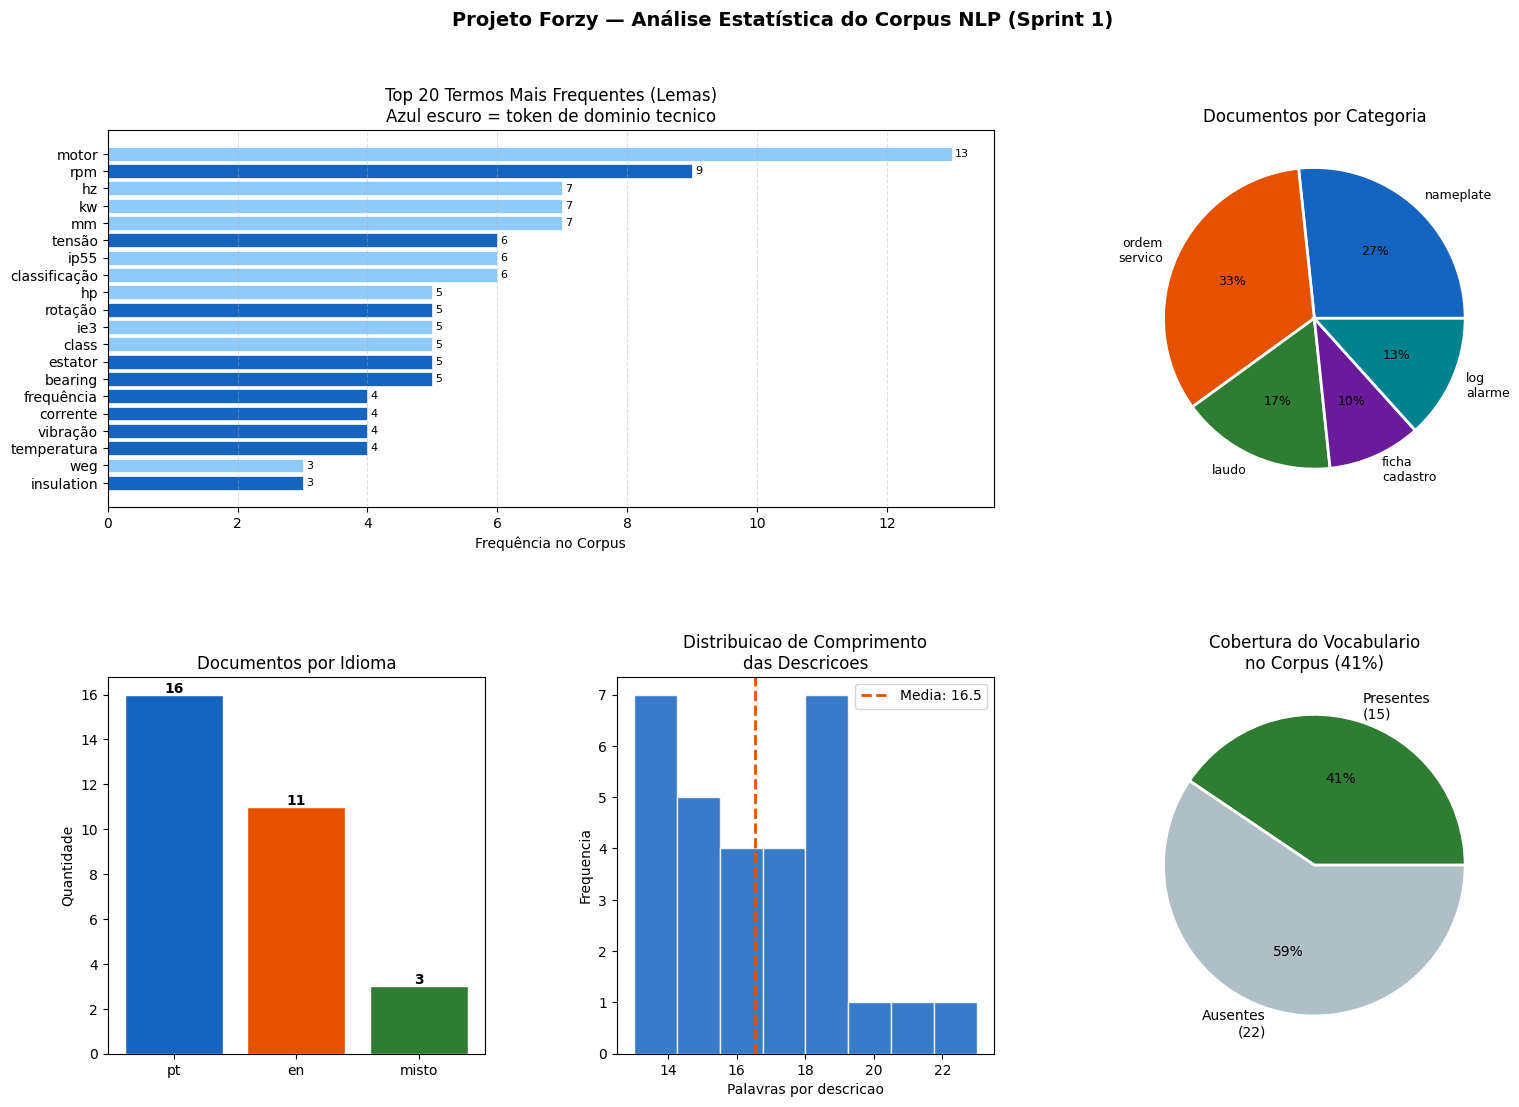

Grafico salvo: forzy_sprint1/outputs/forzy_analise_corpus.png


In [12]:
# ── 4.2 Visualizações estatísticas ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Projeto Forzy — Análise Estatística do Corpus NLP (Sprint 1)",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Top 20 lemas ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
top_n = min(20, len(freq_lemas))
termos_top, freqs_top = zip(*freq_lemas.most_common(top_n))
cores = ["#1565C0" if t in DOMINIO_TOKENS else "#90CAF9" for t in termos_top]
bars = ax1.barh(list(termos_top)[::-1], list(freqs_top)[::-1],
                color=list(cores)[::-1], edgecolor="white", linewidth=0.5)
ax1.set_xlabel("Frequência no Corpus")
ax1.set_title(f"Top {top_n} Termos Mais Frequentes (Lemas)\n"
              "Azul escuro = token de dominio tecnico")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.grid(axis="x", linestyle="--", alpha=0.4)
for bar, freq in zip(bars, list(freqs_top)[::-1]):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(freq), va="center", fontsize=8)

# ── Plot 2: Distribuição por categoria ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
cats = Counter(i["categoria"] for i in corpus)
labels_cat = [c.replace("_", "\n") for c in cats.keys()]
ax2.pie(cats.values(), labels=labels_cat, autopct="%1.0f%%",
        colors=["#1565C0", "#E65100", "#2E7D32", "#6A1B9A", "#00838F"],
        wedgeprops={"linewidth": 2, "edgecolor": "white"},
        textprops={"fontsize": 9})
ax2.set_title("Documentos por Categoria")

# ── Plot 3: Distribuição por idioma ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
langs = Counter(i["idioma"] for i in corpus)
ax3.bar(langs.keys(), langs.values(),
        color=["#1565C0", "#E65100", "#2E7D32"], edgecolor="white")
ax3.set_title("Documentos por Idioma")
ax3.set_ylabel("Quantidade")
for bar, v in zip(ax3.patches, langs.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(v), ha="center", fontsize=10, fontweight="bold")

# ── Plot 4: Comprimento das descrições ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(comprimentos, bins=8, color="#1565C0", edgecolor="white", alpha=0.85)
media = sum(comprimentos) / len(comprimentos)
ax4.axvline(media, color="#E65100", linestyle="--", linewidth=2,
            label=f"Media: {media:.1f}")
ax4.set_xlabel("Palavras por descricao")
ax4.set_ylabel("Frequencia")
ax4.set_title("Distribuicao de Comprimento\ndas Descricoes")
ax4.legend()

# ── Plot 5: Cobertura do glossário (com guarda para valor zero) ───────────────
ax5 = fig.add_subplot(gs[1, 2])

# Recalcula cobertura garantindo que o glossário está disponível
termos_glossario_local = set(glossario.get("termos", {}).keys())
if termos_glossario_local:
    termos_no_corpus_local = termos_glossario_local & vocab_unico
    presentes  = len(termos_no_corpus_local)
    ausentes   = len(termos_glossario_local) - presentes
    cobertura_local = presentes / len(termos_glossario_local) * 100
else:
    # Glossário não carregado: usa tokens de domínio como proxy
    presentes  = len(DOMINIO_TOKENS & vocab_unico)
    ausentes   = len(DOMINIO_TOKENS) - presentes
    cobertura_local = presentes / len(DOMINIO_TOKENS) * 100

cobertura_vals = [presentes, ausentes]

if sum(cobertura_vals) > 0 and all(v >= 0 for v in cobertura_vals):
    ax5.pie(cobertura_vals,
            labels=[f"Presentes\n({presentes})", f"Ausentes\n({ausentes})"],
            autopct="%1.0f%%",
            colors=["#2E7D32", "#B0BEC5"],
            wedgeprops={"linewidth": 2, "edgecolor": "white"},
            textprops={"fontsize": 10})
    ax5.set_title(f"Cobertura do Vocabulario\nno Corpus ({cobertura_local:.0f}%)")
else:
    ax5.text(0.5, 0.5, "Glossario nao\ncarregado",
             ha="center", va="center", fontsize=12, color="gray",
             transform=ax5.transAxes)
    ax5.set_title("Cobertura do Vocabulario")

plt.savefig(PATHS["plot_analise"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafico salvo: {PATHS['plot_analise']}")

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## ⚖️ Bloco 5 — Avaliação: Lematização vs. Stemming

### Por que comparar?
A escolha entre lematização e stemming impacta diretamente a **qualidade do corpus**.  
Avaliamos as duas abordagens em 3 dimensões:
1. **Interpretabilidade** — o resultado é uma palavra válida?
2. **Consistência** — termos de domínio preservados corretamente?
3. **Compressão** — redução do vocabulário

**Decisão adotada:** Lematização (justificativa em `decisoes_padronizacao.md` § 3.3)

In [14]:
# ── 5.1 Comparação quantitativa: lematização vs. stemming ────────────────────

# Métricas comparativas
todos_stems  = [s for item in corpus for s in item["stems"]]
vocab_lemas  = set(todos_lemas)
vocab_stems  = set(todos_stems)

print("=" * 60)
print("⚖️  LEMATIZAÇÃO vs. STEMMING — Análise Comparativa")
print("=" * 60)
print(f"\n{'Métrica':40s} {'Lemas':>10} {'Stems':>10}")
print("-" * 62)
print(f"{'Vocabulário único':40s} {len(vocab_lemas):>10} {len(vocab_stems):>10}")
print(f"{'Total de formas':40s} {len(todos_lemas):>10} {len(todos_stems):>10}")
print(f"{'Type-Token Ratio':40s} {len(vocab_lemas)/len(todos_lemas):>10.4f} {len(vocab_stems)/len(todos_stems):>10.4f}")
print(f"{'Redução de vocabulário vs tokens':40s} {1 - len(vocab_lemas)/len(vocab_unico):>9.1%} {1 - len(vocab_stems)/len(vocab_unico):>9.1%}")

# Exemplos lado a lado
print("\n📋 Exemplos token → lema vs. stem (domínio industrial):")
print(f"\n{'Token Original':22s} {'Lema (spaCy)':22s} {'Stem (RSLP)':22s} {'Interpretável?'}")
print("-" * 90)

exemplos_tokens = [
    "rolamentos", "enrolamentos", "substituição", "danificada",
    "detectado", "aquecimento", "vibração", "desgastados",
    "bearing", "detected", "overheating", "windings"
]

for tok in exemplos_tokens:
    idioma = "pt" if tok in ["rolamentos", "enrolamentos", "substituição", "danificada",
                              "detectado", "aquecimento", "vibração", "desgastados"] else "en"
    doc = NLP_PT(tok) if idioma == "pt" else NLP_EN(tok)
    lema = doc[0].lemma_ if doc else tok
    stem = STEMMER_PT.stem(tok) if idioma == "pt" else STEMMER_EN.stem(tok)
    # Avalia se o stem é uma palavra real (heurística: no vocabulário spaCy)
    stem_valido = "✅" if len(stem) > 2 and stem in lema[:6] else "⚠️ radical"
    print(f"  {tok:20s} {lema:22s} {stem:22s} {stem_valido}")

⚖️  LEMATIZAÇÃO vs. STEMMING — Análise Comparativa

Métrica                                       Lemas      Stems
--------------------------------------------------------------
Vocabulário único                               201        201
Total de formas                                 351        351
Type-Token Ratio                             0.5726     0.5726
Redução de vocabulário vs tokens              0.0%      0.0%

📋 Exemplos token → lema vs. stem (domínio industrial):

Token Original         Lema (spaCy)           Stem (RSLP)            Interpretável?
------------------------------------------------------------------------------------------
  rolamentos           rolamento              rol                    ✅
  enrolamentos         enrolamento            enrol                  ✅
  substituição         substituição           substitu               ⚠️ radical
  danificada           danificar              danific                ⚠️ radical
  detectado            detectar       

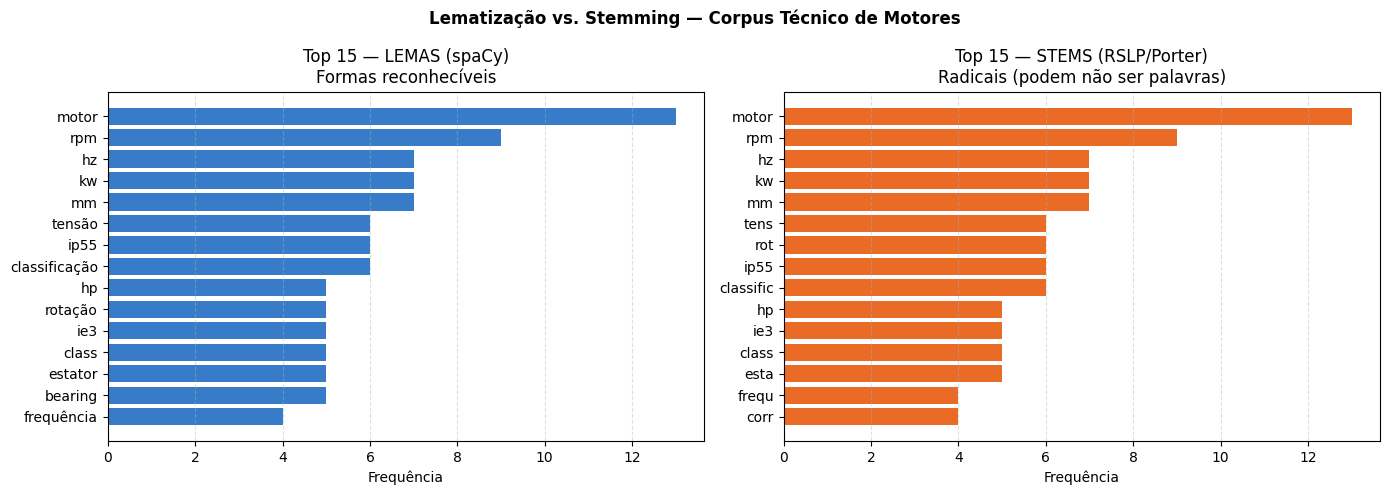

✅ Gráfico salvo: forzy_sprint1/outputs/forzy_comparacao_lemma_stem.png

💡 Conclusão: Lematização preserva 201 formas legíveis vs 201 radicais do stemming.
   Para matching com o glossário técnico, lematização é superior.


In [15]:
# ── 5.2 Visualização comparativa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lematização vs. Stemming — Corpus Técnico de Motores",
             fontsize=12, fontweight="bold")

# Top 15 lemas
ax = axes[0]
top15_lemas = freq_lemas.most_common(15)
t_l, f_l = zip(*top15_lemas)
ax.barh(list(t_l)[::-1], list(f_l)[::-1], color="#1565C0", alpha=0.85)
ax.set_title("Top 15 — LEMAS (spaCy)\nFormas reconhecíveis")
ax.set_xlabel("Frequência")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Top 15 stems
ax = axes[1]
freq_stems = Counter(todos_stems)
top15_stems = freq_stems.most_common(15)
t_s, f_s = zip(*top15_stems)
ax.barh(list(t_s)[::-1], list(f_s)[::-1], color="#E65100", alpha=0.85)
ax.set_title("Top 15 — STEMS (RSLP/Porter)\nRadicais (podem não ser palavras)")
ax.set_xlabel("Frequência")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(PATHS["plot_lemvstem"], dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {PATHS['plot_lemvstem']}")
print(f"\n💡 Conclusão: Lematização preserva {len(vocab_lemas)} formas legíveis vs "
      f"{len(vocab_stems)} radicais do stemming.")
print("   Para matching com o glossário técnico, lematização é superior.")

---
## 💾 Bloco 6 — Exportação do Corpus Estruturado

Gera os artefatos finais da Sprint 1 no formato e estrutura definidos nas **Decisões de Padronização**.

| Artefato | Formato | Destino |
|----------|---------|--------|
| Corpus bruto | CSV | `data/raw/forzy_corpus_raw.csv` |
| Corpus processado | JSON | `data/processed/forzy_corpus_estruturado.json` |
| Estatísticas | JSON | `data/processed/forzy_corpus_stats.json` |
| Glossário técnico | JSON | `docs/forzy_glossario_tecnico.json` |
| Análise corpus | PNG | `outputs/forzy_analise_corpus.png` |
| Comparação lema/stem | PNG | `outputs/forzy_comparacao_lemma_stem.png` |

In [16]:
# ── 6.1 Monta e exporta corpus estruturado JSON ───────────────────────────────

corpus_export = {
    "projeto":  "Forzy Digital Twin",
    "sprint":   1,
    "versao":   "1.0.0",
    "data_processamento": DATA_EXTRACAO,
    "pipeline": [
        {"etapa": 1, "nome": "detect_language",    "descricao": "Detecção de idioma por heurística + langdetect"},
        {"etapa": 2, "nome": "expand_abreviacoes",  "descricao": "Expansão de abreviações industriais via regex com word boundaries"},
        {"etapa": 3, "nome": "normalize",           "descricao": "Lowercase + normalização unicode NFC"},
        {"etapa": 4, "nome": "separate_units",      "descricao": "Separação de valores numéricos e unidades coladas (440V → 440 v)"},
        {"etapa": 5, "nome": "remove_noise",        "descricao": "Remoção de ruído: pontuação, números isolados, underscores"},
        {"etapa": 6, "nome": "tokenize",            "descricao": "Tokenização por whitespace com remoção de stopwords técnicas"},
        {"etapa": 7, "nome": "lemmatize",           "descricao": "Lematização spaCy PT/EN com preservação de tokens de domínio"},
    ],
    "estatisticas": {
        "total_documentos":         len(corpus),
        "total_tokens":             len(todos_tokens),
        "total_lemas":              len(todos_lemas),
        "vocabulario_unico":        len(vocab_unico),
        "type_token_ratio":         round(len(vocab_unico) / len(todos_lemas), 4),
        "comprimento_medio_palavras": round(sum(comprimentos) / len(comprimentos), 2),
        "comprimento_min_palavras": min(comprimentos),
        "comprimento_max_palavras": max(comprimentos),
        "abreviacoes_expandidas":   total_abreviacoes,
        "taxa_compressao_media":    round(sum(c["compressao_pipeline"] for c in corpus) / len(corpus), 3),
        "cobertura_glossario_pct":  round(cobertura_pct, 1),
        "top_20_lemas":             dict(freq_lemas.most_common(20)),
        "distribuicao_idioma":      dict(Counter(i["idioma"] for i in corpus)),
        "distribuicao_categoria":   dict(Counter(i["categoria"] for i in corpus)),
        "distribuicao_fonte":       dict(Counter(i["fonte"] for i in corpus)),
        "fabricantes":              dict(Counter(i["fabricante"] for i in corpus)),
    },
    "vocabulario_controlado": {
        "n_abreviacoes_mapeadas":   len(ABREVIACOES),
        "n_tokens_dominio":         len(DOMINIO_TOKENS),
        "n_stopwords_tecnicos":     len(STOPWORDS_TECNICOS),
        "n_fabricantes_norm":       len(FABRICANTES_NORM),
    },
    "corpus": [
        {
            # Campos de identificação
            "id":                 item["id"],
            "tag":                item["tag"],
            "fabricante":         item["fabricante"],
            "modelo":             item["modelo"],
            "localizacao":        item["localizacao"],
            # Campos textuais originais
            "descricao_curta":    item["descricao_curta"],
            "descricao_longa":    item["descricao_longa"],
            # Metadados de origem
            "fonte":              item["fonte"],
            "categoria":          item["categoria"],
            "idioma":             item["idioma"],
            "idioma_detectado":   item["idioma_detectado"],
            "data_extracao":      item["data_extracao"],
            # Especificação técnica estruturada
            "especificacao_tecnica": item.get("especificacao_tecnica", {}),
            # Campos processados pelo pipeline
            "tokens":             item["tokens"],
            "lemas":              item["lemas"],
            # Métricas por documento
            "num_tokens":         item["num_tokens"],
            "num_lemas":          item["num_lemas"],
            "n_abreviacoes_expandidas": item["n_abreviacoes"],
            "compressao_pipeline":item["compressao_pipeline"],
        }
        for item in corpus
    ]
}

# Exporta corpus
with open(PATHS["corpus_json"], "w", encoding="utf-8") as f:
    json.dump(corpus_export, f, ensure_ascii=False, indent=2)

print(f"✅ Corpus estruturado exportado: {PATHS['corpus_json']}")

✅ Corpus estruturado exportado: forzy_sprint1/data/processed/forzy_corpus_estruturado.json


In [17]:
# ── 6.2 Exporta estatísticas separadas ───────────────────────────────────────
stats_export = corpus_export["estatisticas"].copy()
stats_export["projeto"] = "Forzy Digital Twin"
stats_export["sprint"]  = 1
stats_export["data_processamento"] = DATA_EXTRACAO
stats_export["metricas_qualidade"] = {
    "ttr_meta_atingida":             0.3 <= len(vocab_unico)/len(todos_lemas) <= 0.7,
    "cobertura_glossario_atingida":  cobertura_pct >= 60,
    "metodo_normalizacao":           "lematizacao_spacy",
    "motivo_escolha_lematizacao":    "Preserva formas legíveis; melhor matching com glossário técnico",
}

with open(PATHS["stats_json"], "w", encoding="utf-8") as f:
    json.dump(stats_export, f, ensure_ascii=False, indent=2)

print(f"✅ Estatísticas exportadas: {PATHS['stats_json']}")

✅ Estatísticas exportadas: forzy_sprint1/data/processed/forzy_corpus_stats.json


In [18]:
# ── 6.3 Validação final dos artefatos ────────────────────────────────────────

print("🔍 VALIDAÇÃO FINAL DOS ARTEFATOS")
print("=" * 55)

artefatos_check = [
    (PATHS["raw_csv"],       "Corpus bruto CSV"),
    (PATHS["corpus_json"],   "Corpus estruturado JSON"),
    (PATHS["stats_json"],    "Estatísticas JSON"),
    (PATHS["glossario"],     "Glossário técnico JSON"),
    (PATHS["plot_analise"],  "Gráfico análise corpus"),
    (PATHS["plot_lemvstem"], "Gráfico lema vs stem"),
]

todos_ok = True
for path, nome in artefatos_check:
    if path.exists():
        tamanho = path.stat().st_size
        print(f"  ✅ {nome:35s} {tamanho:7,d} bytes → {path.name}")
    else:
        print(f"  ❌ {nome:35s} NÃO ENCONTRADO → {path.name}")
        todos_ok = False

# Valida integridade do corpus JSON
with open(PATHS["corpus_json"], "r", encoding="utf-8") as f:
    cv = json.load(f)

print(f"\n📋 Corpus JSON — verificação de integridade:")
print(f"   Documentos no arquivo:  {len(cv['corpus'])}")
print(f"   Campos por documento:   {len(cv['corpus'][0].keys())}")
campos_obrigatorios = ["id", "tag", "fabricante", "localizacao", "fonte",
                       "categoria", "idioma", "data_extracao", "lemas",
                       "especificacao_tecnica"]
faltando = [c for c in campos_obrigatorios if c not in cv["corpus"][0]]
print(f"   Campos obrigatórios:    {'✅ todos presentes' if not faltando else '❌ faltando: ' + str(faltando)}")

print(f"\n{'✅ SPRINT 1 CONCLUÍDA COM SUCESSO!' if todos_ok else '⚠️ Verifique os artefatos faltando.'}")

🔍 VALIDAÇÃO FINAL DOS ARTEFATOS
  ✅ Corpus bruto CSV                      9,666 bytes → forzy_corpus_raw.csv
  ✅ Corpus estruturado JSON              40,583 bytes → forzy_corpus_estruturado.json
  ✅ Estatísticas JSON                     1,484 bytes → forzy_corpus_stats.json
  ✅ Glossário técnico JSON               17,180 bytes → forzy_glossario_tecnico.json
  ✅ Gráfico análise corpus              230,015 bytes → forzy_analise_corpus.png
  ✅ Gráfico lema vs stem                 91,029 bytes → forzy_comparacao_lemma_stem.png

📋 Corpus JSON — verificação de integridade:
   Documentos no arquivo:  30
   Campos por documento:   19
   Campos obrigatórios:    ✅ todos presentes

✅ SPRINT 1 CONCLUÍDA COM SUCESSO!


In [19]:
# ── 6.4 Resumo executivo para o professor ────────────────────────────────────
print("="*65)
print("📝 RESUMO EXECUTIVO — SPRINT 1 | PROJETO FORZY")
print("="*65)
print(f"""
ENTREGÁVEIS GERADOS:
  1. Dataset Sintético:     30 registros | 5 categorias | 3 idiomas
                            8 fabricantes | 6 TAGs de equipamento
  2. Glossário Técnico:     40 termos PT/EN | 8 categorias semânticas
                            Vocabulário controlado: fabricantes, TAGs, normas
  3. Pipeline NLP (7 etapas):
                            E1 Detecção de idioma (heurística + langdetect)
                            E2 Expansão de abreviações ({len(ABREVIACOES)} padrões regex)
                            E3 Normalização unicode NFC
                            E4 Separação valor+unidade (440V → 440 v)
                            E5 Remoção de ruído
                            E6 Tokenização + stopwords técnicas
                            E7 Lematização spaCy PT/EN
  4. Análise Estatística:
                            Vocabulário único:   {len(vocab_unico)} termos
                            TTR:                 {len(vocab_unico)/len(todos_lemas):.3f}
                            Comprimento médio:   {sum(comprimentos)/len(comprimentos):.1f} palavras/doc
                            Cobertura glossário: {cobertura_pct:.0f}%
  5. Avaliação Lema vs Stem: Lematização adotada (formas legíveis,
                             matching glossário superior)
  6. Corpus Estruturado:   JSON com {len(campos_obrigatorios)} campos obrigatórios
                            incluindo: tag, fonte, data_extracao,
                            idioma, especificacao_tecnica

ESTRUTURA DE DIRETÓRIOS:
  forzy_sprint1/data/raw/       → corpus bruto CSV
  forzy_sprint1/data/processed/ → corpus JSON + estatísticas
  forzy_sprint1/docs/           → glossário + decisões de padronização
  forzy_sprint1/outputs/        → visualizações PNG

PRÓXIMOS PASSOS (Sprint 2):
  → Word Embeddings (Word2Vec/FastText) treinados no corpus
  → NER para entidades: [COMPONENTE] [MEDIDA] [FALHA] [TAG]
  → Fine-tuning BERT multilíngue no domínio industrial
  → Consulta semântica sobre o corpus estruturado
""")
print("="*65)

📝 RESUMO EXECUTIVO — SPRINT 1 | PROJETO FORZY

ENTREGÁVEIS GERADOS:
  1. Dataset Sintético:     30 registros | 5 categorias | 3 idiomas
                            8 fabricantes | 6 TAGs de equipamento
  2. Glossário Técnico:     40 termos PT/EN | 8 categorias semânticas
                            Vocabulário controlado: fabricantes, TAGs, normas
  3. Pipeline NLP (7 etapas):
                            E1 Detecção de idioma (heurística + langdetect)
                            E2 Expansão de abreviações (22 padrões regex)
                            E3 Normalização unicode NFC
                            E4 Separação valor+unidade (440V → 440 v)
                            E5 Remoção de ruído
                            E6 Tokenização + stopwords técnicas
                            E7 Lematização spaCy PT/EN
  4. Análise Estatística:
                            Vocabulário único:   201 termos
                            TTR:                 0.573
                            Comprime

---
## 📁 Estrutura Final de Artefatos

```
forzy_sprint1/
├── data/
│   ├── raw/
│   │   └── forzy_corpus_raw.csv              ← 30 descrições técnicas originais
│   └── processed/
│       ├── forzy_corpus_estruturado.json     ← Corpus com todos os campos + lemas
│       └── forzy_corpus_stats.json           ← Métricas e estatísticas
├── docs/
│   ├── forzy_glossario_tecnico.json          ← 40 termos PT/EN estruturados
│   └── decisoes_padronizacao.md             ← Justificativas técnicas
└── outputs/
    ├── forzy_analise_corpus.png             ← 5 visualizações estatísticas
    └── forzy_comparacao_lemma_stem.png      ← Comparação quantitativa
```

---
*Projeto Forzy — Sprint 1 PLN | Challenge FIAP | v1.0.0*